# 03 — Modelação (walk-forward)

Treina os 3 modelos com validação walk-forward e inspeciona o AUC out-of-sample.

In [1]:
import sys; sys.path.append('..')
from src.fetch_data import load_config
from src.features import TARGET_COL
from src.train import run_walk_forward
from src.evaluate import compute_auc
import pandas as pd

config = load_config('../config.yaml')
df = pd.read_parquet('../' + config['data']['processed_path'])
labelled = df[df[TARGET_COL].notna()].copy()

In [2]:
preds = run_walk_forward(labelled, config)
compute_auc(preds)

Walk-forward: 342 passos, treino mínimo 180 meses.
  -logistic concluído.
  -random_forest concluído.
  -xgboost concluído.


{'logistic': 0.7836669699727024,
 'random_forest': 0.8698248407643312,
 'xgboost': 0.8837579617834395}

<Axes: title={'center': 'Prob. prevista (OOS)'}>

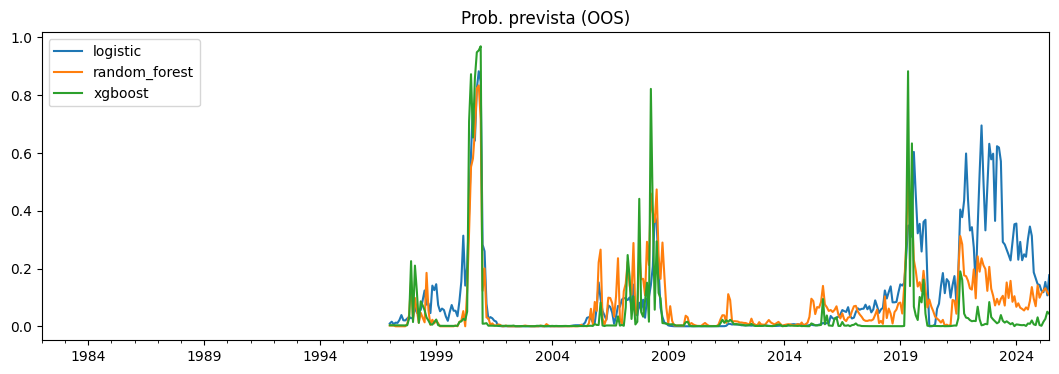

In [3]:
preds[['logistic','random_forest','xgboost']].plot(figsize=(13,4), title='Prob. prevista (OOS)')